In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 5** - Chemical Process Optimisation

- A black box function which represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised.

- **Main goal** - find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

- **Input** - 4D (20,4)
- **Output** - 4D (20,)

- **Goal** - Maximise


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_5\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_5\initial_outputs.npy')

### **Random search**

- This is the fist simple method to get a query just to explore thorugh trial-and-error method to just get a guage of the space.


In [3]:
next_query = np.random.uniform(size = 4)
print(next_query)

[0.19033994 0.17124848 0.28562119 0.2704661 ]


### **Bayesian Optimisation - Matern Gaussian Process**


- Since the function is unimodal, we want more smoothness than we used in the warehouse problem.
  - Matern 5/2 is twice differentiable, allowing the model to smoothly "round off" the top of the peak for more precise maximization.

- Additionally, I have made a provisition to add a noise element in with the value of `1e-5`.
  - Typically, in chemical yeild experiments in a factory setting usually have high repeatability.
  - This lower noise value allows the model to intially trust the 20 data points.


In [ ]:
kernel = Matern(length_scale=[1.0]*4, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    alpha=1e-5,
    normalize_y=True,
    random_state=42
)

model.fit(X, Y)

GaussianProcessRegressor(alpha=1e-05, kernel=Matern(length_scale=1, nu=2.5),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement


- As EI is an industry standard for 4D+ spaces because _tt excels at balancing the "**high risk/high reward**" of unexplored areas with the "**safe bet**" of refining near existing good results._


In [5]:
def expected_improvement(X_grid, model, y_max, xi=0.01):

    mu, sigma = model.predict(X_grid, return_std=True)

    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0

    return ei.ravel()

# Calculate the values using the function
y_max = np.max(Y)
x_grid = np.random.uniform(0, 1, size=(100000, 4))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

# Find the best index from the calculated values

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 5 - Bayesian Optimisation (EI): "
f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")


Next Submission for Function 5 - Bayesian Optimisation (EI): 0.243934-0.863597-0.948510-0.929594


### **Visualisation of the Progression based on initial inputs**


- For a unimodal function, you should see the trend line gradually "climbing" a slope. If you see a point that is significantly higher than its neighbors, the 4D label underneath it represents the current best input for the yield.

- Since we are working with a transformed output means that by maximizing this value, you are simultaneously maximizing yield and minimizing side effects.


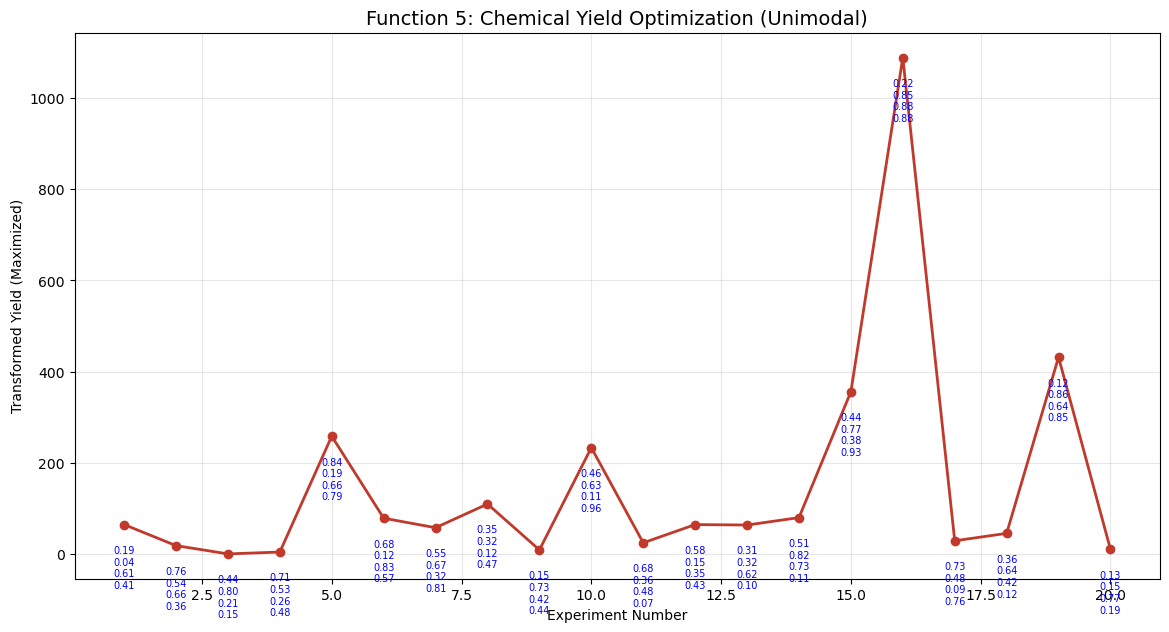

In [10]:
iterations = np.arange(1, len(Y) + 1)
plt.figure(figsize=(14, 7))
plt.plot(iterations, Y, marker='o', linestyle='-', color='#c0392b', linewidth=2)

for i in range(len(Y)):
    # Stacked inputs: x1 (temp), x2 (pressure), x3 (conc), x4 (time)
    input_label = f"{X[i,0]:.2f}\n{X[i,1]:.2f}\n{X[i,2]:.2f}\n{X[i,3]:.2f}"
    
    plt.annotate(input_label, 
                 (iterations[i], Y[i]), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 va='top', 
                 ha='center', 
                 fontsize=7,
                 linespacing=1.2,
                 color = 'blue')

plt.title('Function 5: Chemical Yield Optimization (Unimodal)', fontsize=14)
plt.xlabel('Experiment Number')
plt.ylabel('Transformed Yield (Maximized)')
plt.subplots_adjust(bottom=0.1) # Extra space for stacked labels
plt.grid(True, alpha=0.3)
plt.show()

### **Reasons for having a different input values for week 1 than what is shown here**

**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.55421-0.123984-0.678221-0.890122]

- I will be using this thinking process and methodology moving forward into week 2.
